## Pricing Analyst

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

df = pd.read_csv('air_fryers_clean_brand_year.csv')

feature_cols =[
    'compact_share', 
    'dual_basket_share', 
    'oven_style_share', 
    'rotisserie_share', 
    'window_share'
]

brand_dummies = pd.get_dummies(df['brand'], prefix='brand', drop_first=True, dtype=int)
year_dummies = pd.get_dummies(df['year'].astype(str), prefix='year', drop_first=True, dtype=int)

X = pd.concat([
    df[['avg_price', 'avg_rating'] + feature_cols],
    brand_dummies,
    year_dummies
], axis=1)

model = LinearRegression()
model.fit(X, df['log_brand_share'])

coef_table = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
})

price_coef = coef_table.loc[coef_table['feature'] == 'avg_price', 'coefficient'].iloc[0]

df['demand_slope'] = price_coef * df['brand_share'] * (1 - df['brand_share'])
df['unit_cost'] = df['avg_price'] + (df['brand_share'] / df['demand_slope'])
df['markup'] = df['avg_price'] - df['unit_cost']
df['average_profit'] = df['brand_share'] * df['markup']

brand_metrics = df.groupby('brand')[['unit_cost', 'markup', 'average_profit']].mean()
print(brand_metrics.sort_values(by='average_profit', ascending=False))
print("\nNegative unit costs count:", (df['unit_cost'] < 0).sum())

              unit_cost     markup  average_profit
brand                                             
ninja        112.488470  32.854071        6.306093
instant_pot   71.903119  32.558234        6.010256
gowise usa    56.301040  31.153741        4.605764
dash          27.936578  29.542349        2.994372
chefman       61.569466  29.368946        2.820968
ultrean       48.785765  29.328841        2.780864
cuisinart    194.896119  29.050974        2.502997
cosori        86.283321  27.984628        1.436651
nuwave       109.053549  27.970835        1.422858
oster        161.804969  27.226315        0.678338

Negative unit costs count: 0


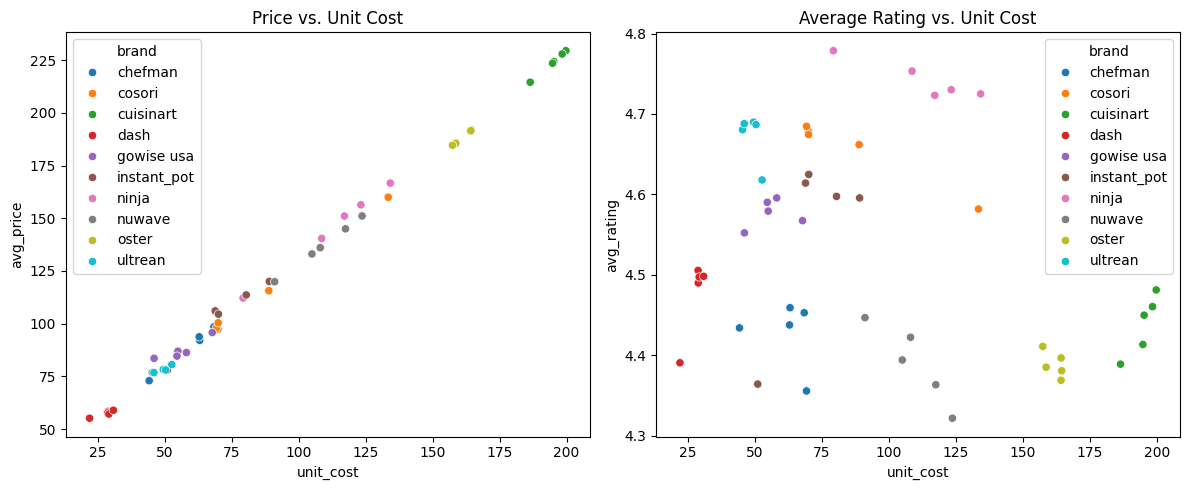

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=df, x='unit_cost', y='avg_price', hue='brand', ax=axes[0])
axes[0].set_title('Price vs. Unit Cost')

sns.scatterplot(data=df, x='unit_cost', y='avg_rating', hue='brand', ax=axes[1])
axes[1].set_title('Average Rating vs. Unit Cost')

plt.tight_layout()
plt.show()

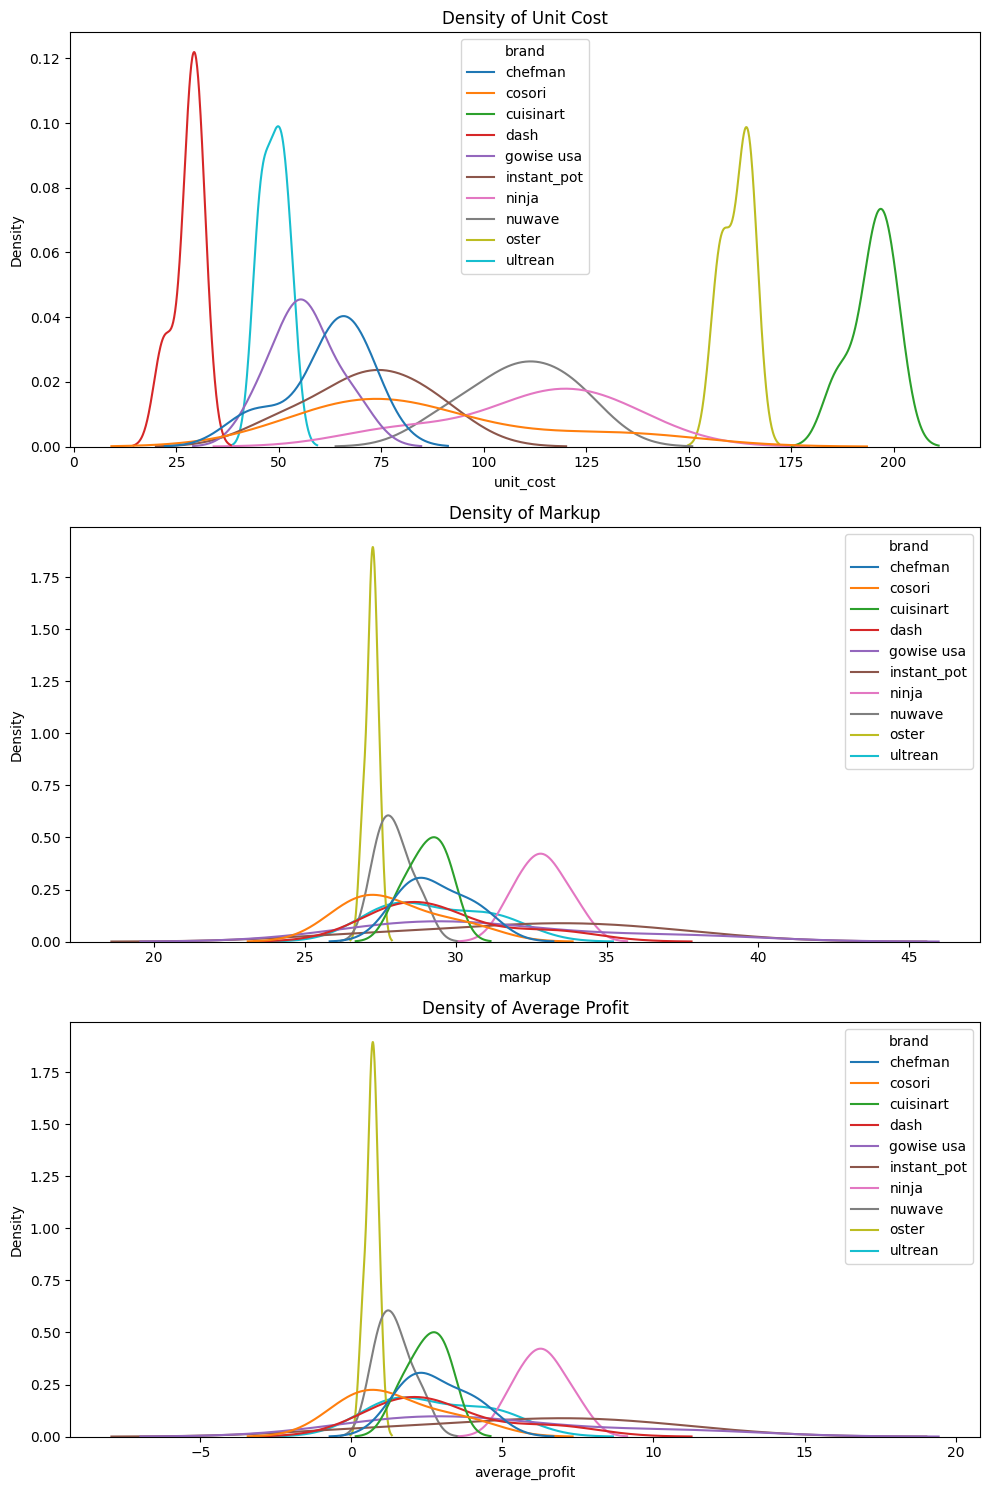

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

sns.kdeplot(data=df, x='unit_cost', hue='brand', ax=axes[0], common_norm=False)
axes[0].set_title('Density of Unit Cost')

sns.kdeplot(data=df, x='markup', hue='brand', ax=axes[1], common_norm=False)
axes[1].set_title('Density of Markup')

sns.kdeplot(data=df, x='average_profit', hue='brand', ax=axes[2], common_norm=False)
axes[2].set_title('Density of Average Profit')

plt.tight_layout()
plt.show()